# 4.6 Conditional Sensitivity to Initial Yield Curve

Evaluates how sensitive each model is to the initial yield curve by comparing
the **Nelson-Siegel factor distributions (β₁, β₂, β₃)** across three interest rate regimes.
Change  in the Setup cell to switch between full horizon (60) and short-term (12).


## Setup & Data Loading

import pandas as pd

# Load CSV
df = pd.read_csv("VAE.csv")

# Remove 2nd and 3rd columns
df = df.drop(df.columns[[1, 2]], axis=1)

# Save new CSV
df.to_csv("VAE_3 scenarios 10-5.csv", index=False)

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
from scipy.stats import wasserstein_distance
import warnings
warnings.filterwarnings("ignore")

# ── Maturity labels ─────────────────────────────────────────────────────────
MATURITIES = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
MAT_YEARS  = np.array([1/12,3/12,6/12,1,2,3,5,7,10,20,30])

MAT_MONTHS = MAT_YEARS * 12   # λ is calibrated for maturities in months

# ── Nelson-Siegel (fixed λ) ─────────────────────────────────────────────────
LAMBDA = 0.0609
def ns_basis(t, lam=LAMBDA):
    lt = lam * t
    return np.column_stack([np.ones_like(t),
                            (1-np.exp(-lt))/lt,
                            (1-np.exp(-lt))/lt - np.exp(-lt)])
NS_BASIS = ns_basis(MAT_MONTHS)   # (11, 3)

# ── Regime labels & colours ─────────────────────────────────────────────────
REGIMES = {
    1: "High-rate (2002-2004)",
    2: "Medium-rate (2012-2014)",
    3: "Low-rate (2018-2021)",
}
REGIME_COLORS = {1: "#C62828", 2: "#E6AC00", 3: "#1565C0"}

# ── Model colours ───────────────────────────────────────────────────────────
MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#2E7D32",
    "CANN":      "#8E24AA",
    "VAE":       "#EF6C00",
}

# ── HORIZON CONTROL — change this to 12 or 60 ───────────────────────────────
N_MONTHS = 60   # ← single variable controlling the analysis horizon


In [61]:
# ── Data loader ────────────────────────────────────────────────────────────
def _detect_mat_cols(df):
    bare     = [m for m in MATURITIES if m in df.columns]
    prefixed = [f"Y_{m}" for m in MATURITIES if f"Y_{m}" in df.columns]
    if len(bare)     == 11: return bare
    if len(prefixed) == 11: return prefixed
    raise ValueError(f"Cannot find maturity columns in {list(df.columns)}")

def load_conditional_data(path, n_scen=200):
    """Returns {regime_id: list of (T, 11) arrays}"""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    mat_cols = _detect_mat_cols(df)
    result = {}
    if "Start_Curve_ID" in df.columns:
        for rid in sorted(df["Start_Curve_ID"].unique()):
            sub  = df[df["Start_Curve_ID"] == rid]
            wins = [sub[sub["Scenario_ID"]==sid][mat_cols].values.astype(float)
                    for sid in sub["Scenario_ID"].unique()[:n_scen]]
            result[int(rid)] = [w for w in wins if w.shape[0] >= N_MONTHS]
    else:
        wins = [df[df["Scenario_ID"]==sid][mat_cols].values.astype(float)
                for sid in df["Scenario_ID"].unique()[:n_scen]]
        result[1] = [w for w in wins if w.shape[0] >= N_MONTHS]
    return result

# ── Fit all three β factors for first N_MONTHS of each scenario ─────────────
def extract_betas(windows, n_months=N_MONTHS):
    """
    windows : list of (T, 11) arrays
    returns : (N_scen * n_months, 3) array — β1, β2, β3 for each timestep
    """
    betas = []
    for w in windows:
        for t in range(n_months):
            b, *_ = lstsq(NS_BASIS, w[t], rcond=None)
            betas.append(b)
    return np.array(betas)   # (N*n_months, 3)

# ── Load models ─────────────────────────────────────────────────────────────
MODELS = {
    "Diffusion": "diffusion_3 scenarios 6-5.csv",
    "HJM-PCA":   "hjm_pca_3 scenarios 6-5.csv",
    "CANN":    "cann_3 scenarios 10-5.csv",
    "VAE":     "VAE_3 scenarios 10-5.csv",
}

model_betas = {}   # model → {regime_id → (N*n_months, 3) array}
for name, path in MODELS.items():
    data = load_conditional_data(path)
    model_betas[name] = {}
    for rid, windows in data.items():
        b = extract_betas(windows)
        model_betas[name][rid] = b
        label = REGIMES.get(rid, f"Curve {rid}")
        print(f"  {name:12s} | {label:28s}: {len(windows):3d} scenarios, "
              f"{b.shape[0]:5d} timesteps  (mean β₂ = {b[:,1].mean():.4f})")

# ── Backward-compatible β₂ dict for existing cells ───────────────────────────
model_beta2 = {name: {rid: b[:,1] for rid, b in rd.items()}
               for name, rd in model_betas.items()}


  Diffusion    | High-rate (2002-2004)       : 200 scenarios, 12000 timesteps  (mean β₂ = -2.7641)
  Diffusion    | Medium-rate (2012-2014)     : 200 scenarios, 12000 timesteps  (mean β₂ = -2.8474)
  Diffusion    | Low-rate (2018-2021)        : 200 scenarios, 12000 timesteps  (mean β₂ = -0.7605)
  HJM-PCA      | High-rate (2002-2004)       : 200 scenarios, 12000 timesteps  (mean β₂ = -2.5681)
  HJM-PCA      | Medium-rate (2012-2014)     : 200 scenarios, 12000 timesteps  (mean β₂ = -1.9072)
  HJM-PCA      | Low-rate (2018-2021)        : 200 scenarios, 12000 timesteps  (mean β₂ = -0.6582)
  CANN         | High-rate (2002-2004)       : 200 scenarios, 12000 timesteps  (mean β₂ = -3.9640)
  CANN         | Medium-rate (2012-2014)     : 200 scenarios, 12000 timesteps  (mean β₂ = -2.7376)
  CANN         | Low-rate (2018-2021)        : 200 scenarios, 12000 timesteps  (mean β₂ = -1.8950)
  VAE          | High-rate (2002-2004)       : 200 scenarios, 12000 timesteps  (mean β₂ = -2.8727)
  VAE     

## All β Factor Distributions per Regime

For each model: β₁, β₂, β₃ distributions across the three regimes side by side.
Based on N_MONTHS setting.


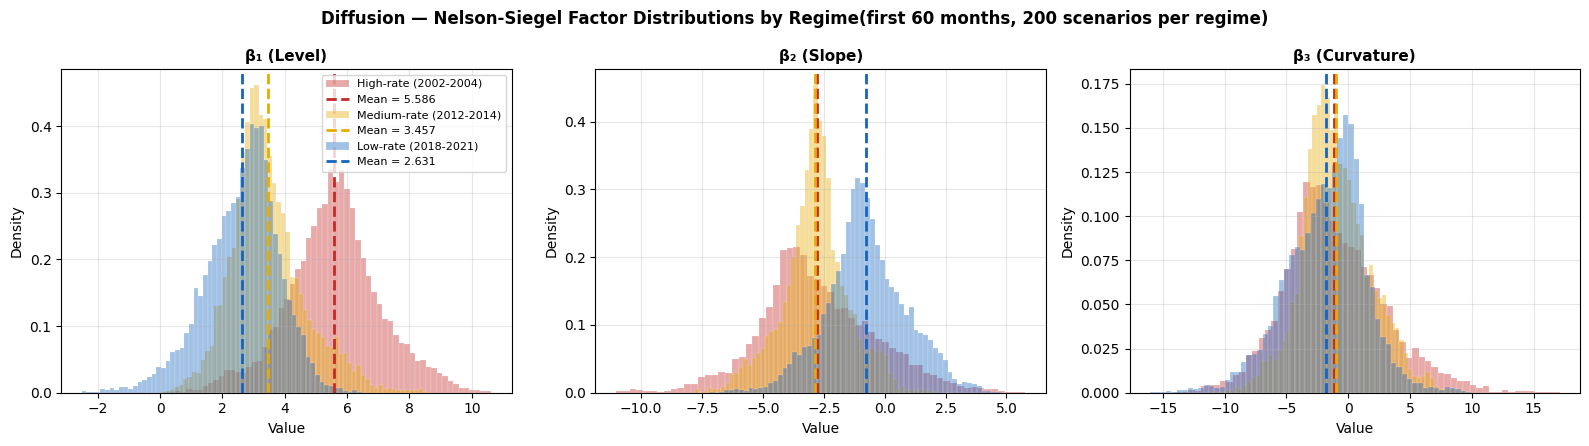

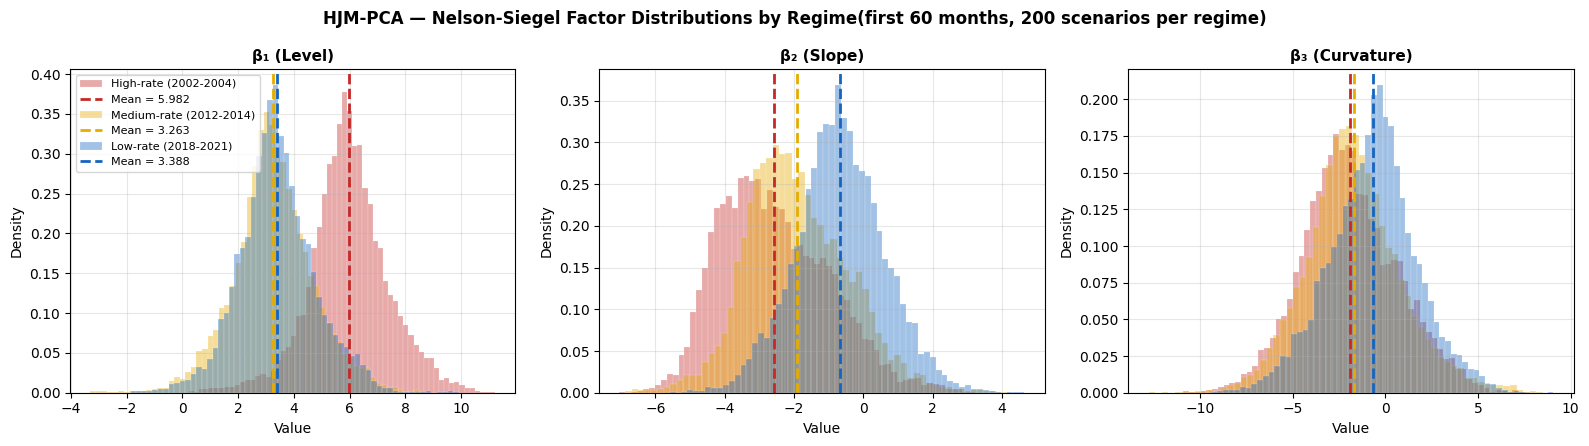

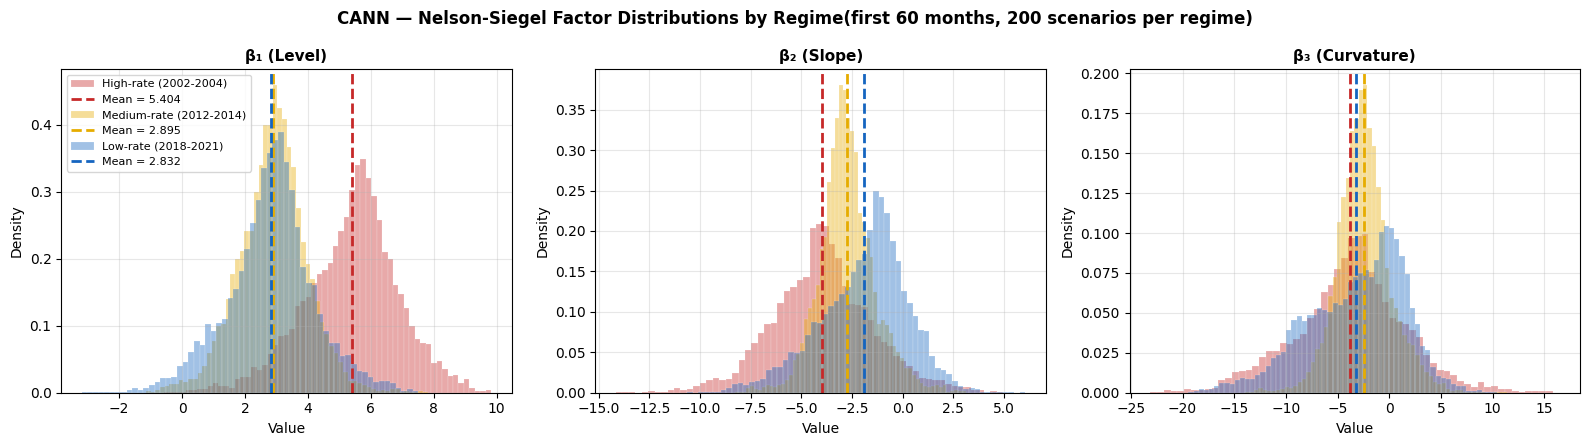

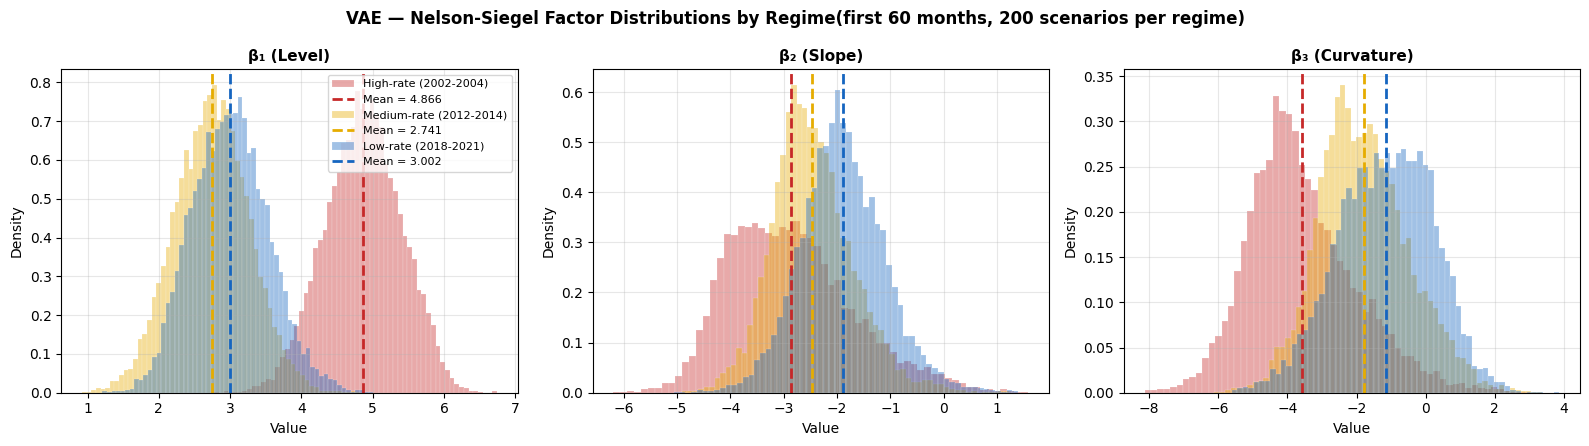

In [62]:
BETA_LABELS = ["β₁ (Level)", "β₂ (Slope)", "β₃ (Curvature)"]

for model_name, regime_betas in model_betas.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"{model_name} — Nelson-Siegel Factor Distributions by Regime"
                 f"(first {N_MONTHS} months, 200 scenarios per regime)",
                 fontsize=12, fontweight="bold")

    for bi, beta_label in enumerate(BETA_LABELS):
        ax = axes[bi]
        for rid, betas in sorted(regime_betas.items()):
            color = REGIME_COLORS[rid]
            label = REGIMES.get(rid, f"Curve {rid}")
            vals  = betas[:, bi]
            mean  = vals.mean()
            ax.hist(vals, bins=60, density=True, alpha=0.40,
                    color=color, edgecolor="white", linewidth=0.3, label=label)
            ax.axvline(mean, color=color, linewidth=2, linestyle="--",
                       label=f"Mean = {mean:.3f}")
        ax.set_title(beta_label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        ax.grid(True, alpha=0.3)
        if bi == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## Wasserstein Distances Between Regime Distributions

Pairwise Wasserstein-1 distance between factor distributions across regimes,
for all three β factors per model.


In [63]:
from itertools import combinations

print("=" * 80)
print(f"  Wasserstein Distances — all β factors across regimes (first {N_MONTHS} months)")
print("=" * 80)

rows = []
for model_name, regime_betas in model_betas.items():
    avail = sorted(regime_betas.keys())
    print(f"{model_name}")
    for a, b in combinations(avail, 2):
        la = REGIMES.get(a, f"Curve {a}").split()[0]
        lb = REGIMES.get(b, f"Curve {b}").split()[0]
        for bi, bl in enumerate(["β₁", "β₂", "β₃"]):
            dist = wasserstein_distance(regime_betas[a][:, bi],
                                        regime_betas[b][:, bi])
            rows.append({
                "Model": model_name,
                "Regime A": REGIMES.get(a, f"Curve {a}"),
                "Regime B": REGIMES.get(b, f"Curve {b}"),
                "Factor": bl,
                "Wasserstein": round(dist, 4),
            })
            print(f"    {la:8s} vs {lb:8s} | {bl}: {dist:.4f}")

wass_df = pd.DataFrame(rows)


  Wasserstein Distances — all β factors across regimes (first 60 months)
Diffusion
    High-rate vs Medium-rate | β₁: 2.1287
    High-rate vs Medium-rate | β₂: 0.8498
    High-rate vs Medium-rate | β₃: 0.9917
    High-rate vs Low-rate | β₁: 2.9551
    High-rate vs Low-rate | β₂: 2.0156
    High-rate vs Low-rate | β₃: 0.7366
    Medium-rate vs Low-rate | β₁: 0.8264
    Medium-rate vs Low-rate | β₂: 2.0869
    Medium-rate vs Low-rate | β₃: 0.8050
HJM-PCA
    High-rate vs Medium-rate | β₁: 2.7191
    High-rate vs Medium-rate | β₂: 0.6619
    High-rate vs Medium-rate | β₃: 0.2184
    High-rate vs Low-rate | β₁: 2.5944
    High-rate vs Low-rate | β₂: 1.9099
    High-rate vs Low-rate | β₃: 1.2442
    Medium-rate vs Low-rate | β₁: 0.1312
    Medium-rate vs Low-rate | β₂: 1.2490
    Medium-rate vs Low-rate | β₃: 1.0611
CANN
    High-rate vs Medium-rate | β₁: 2.5093
    High-rate vs Medium-rate | β₂: 1.3658
    High-rate vs Medium-rate | β₃: 2.3396
    High-rate vs Low-rate | β₁: 2.5719
    Hig

## Volatility Term Structure by Rate Environment

For each model: one plot with three lines (one per regime).
Volatility = std of month-to-month yield changes across the first 12 months, per maturity.
Thin lines = individual scenarios; thick line = mean across all 200 scenarios per regime.


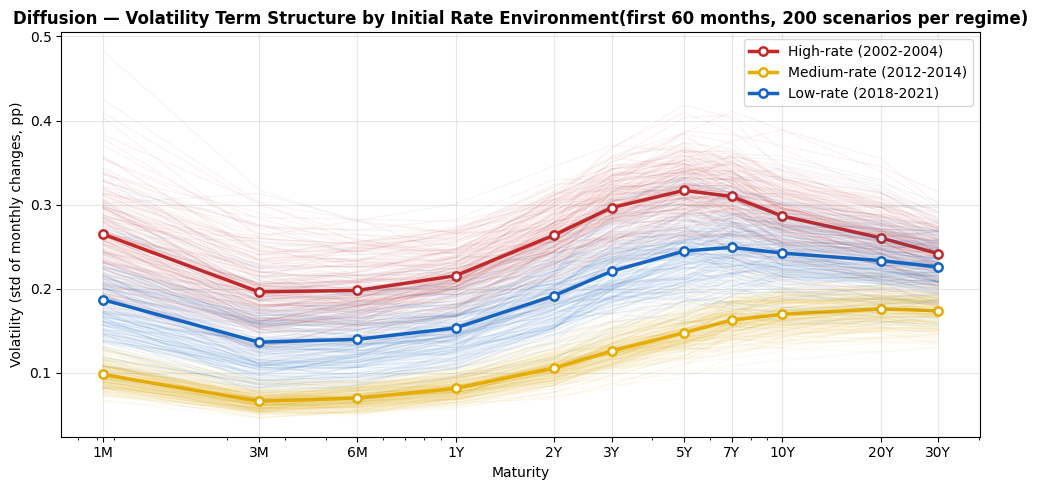

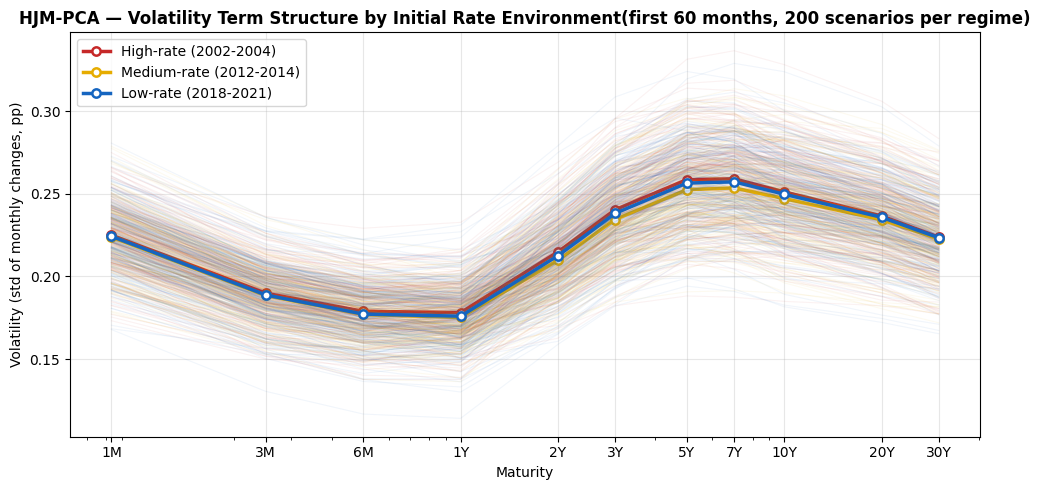

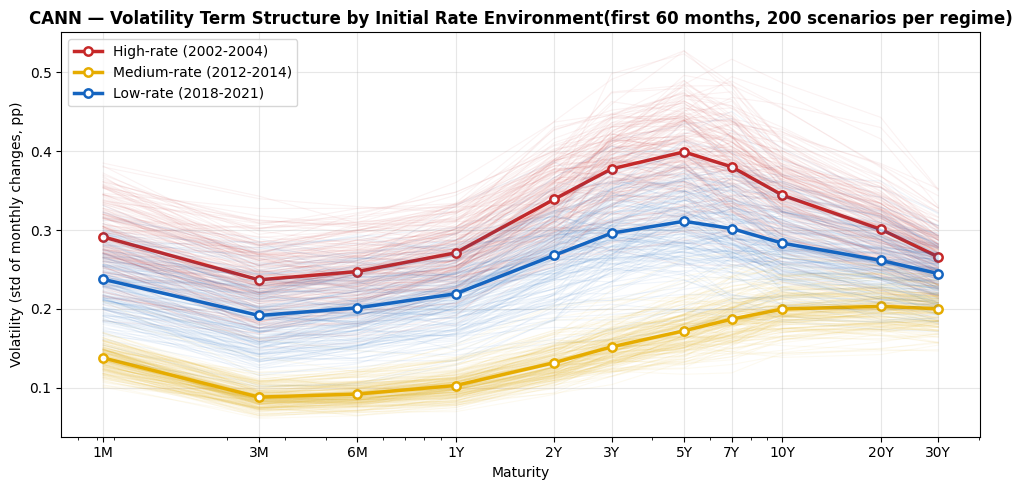

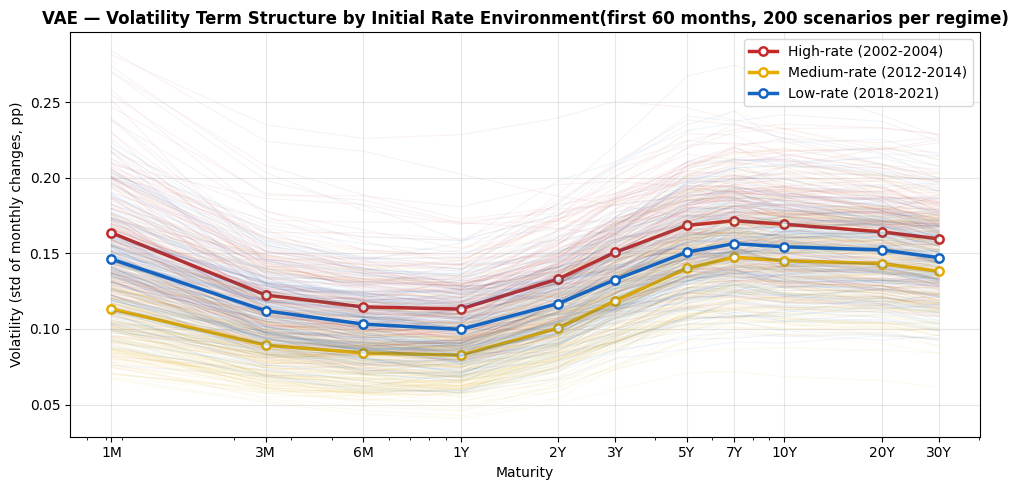

In [64]:
MATURITY_YEARS  = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
MATURITY_LABELS = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]

def vol_curve_from_windows(windows, n_months=N_MONTHS):
    """
    For each scenario window (T, 11), take first n_months rows,
    compute std of monthly changes per maturity.
    Returns array (N_scenarios, 11).
    """
    curves = []
    for w in windows:
        segment = w[:n_months]
        changes = np.diff(segment, axis=0)
        curves.append(changes.std(axis=0))
    return np.array(curves)

MODELS_DATA = {
    "Diffusion": load_conditional_data("diffusion_3 scenarios 6-5.csv"),
    "HJM-PCA":   load_conditional_data("hjm_pca_3 scenarios 6-5.csv"),
    "CANN":    load_conditional_data("cann_3 scenarios 10-5.csv"),
    "VAE":     load_conditional_data("VAE_3 scenarios 10-5.csv"),
}

for model_name, regime_dict in MODELS_DATA.items():
    fig, ax = plt.subplots(figsize=(10, 5))

    for rid, windows in sorted(regime_dict.items()):
        color = REGIME_COLORS[rid]
        label = REGIMES.get(rid, f"Curve {rid}")

        vol_curves = vol_curve_from_windows(windows, n_months=N_MONTHS)

        for v in vol_curves:
            ax.plot(MATURITY_YEARS, v, color=color, alpha=0.06, lw=0.8)

        ax.plot(MATURITY_YEARS, vol_curves.mean(axis=0),
                color=color, lw=2.5,
                marker="o", markersize=6,
                markerfacecolor="white", markeredgewidth=1.8,
                label=label)

    ax.set_xscale("log")
    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(MATURITY_LABELS)
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Volatility (std of monthly changes, pp)")
    ax.set_title(f"{model_name} — Volatility Term Structure by Initial Rate Environment"
                 f"(first {N_MONTHS} months, 200 scenarios per regime)",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [65]:
# ── 1M Volatility: mean per regime + pairwise distances ──────────────────────
from itertools import combinations

MAT_1M_IDX = 0

print("=" * 65)
print(f"  Average 1M Volatility by Model and Rate Environment")
print(f"  (std of monthly yield changes, first {N_MONTHS} months, pp)")
print("=" * 65)

vol_1m = {}

for model_name, regime_dict in MODELS_DATA.items():
    vol_1m[model_name] = {}
    print(f"{model_name}")
    for rid, windows in sorted(regime_dict.items()):
        vc   = vol_curve_from_windows(windows, n_months=N_MONTHS)
        mean = vc[:, MAT_1M_IDX].mean()
        vol_1m[model_name][rid] = mean
        label = REGIMES.get(rid, f"Curve {rid}")
        print(f"    {label:28s}: {mean:.4f} pp")

print()
print("=" * 65)
print("  Pairwise Distances — 1M Volatility across Regimes")
print("  (|mean_vol_A - mean_vol_B|)")
print("=" * 65)

for model_name, rid_means in vol_1m.items():
    avail = sorted(rid_means.keys())
    print(f"{model_name}")
    for a, b in combinations(avail, 2):
        dist  = abs(rid_means[a] - rid_means[b])
        la    = REGIMES.get(a, f"Curve {a}").split()[0]
        lb    = REGIMES.get(b, f"Curve {b}").split()[0]
        print(f"    {la:8s} vs {lb:8s}: {dist:.4f} pp")


  Average 1M Volatility by Model and Rate Environment
  (std of monthly yield changes, first 60 months, pp)
Diffusion
    High-rate (2002-2004)       : 0.2649 pp
    Medium-rate (2012-2014)     : 0.0982 pp
    Low-rate (2018-2021)        : 0.1870 pp
HJM-PCA
    High-rate (2002-2004)       : 0.2250 pp
    Medium-rate (2012-2014)     : 0.2238 pp
    Low-rate (2018-2021)        : 0.2243 pp
CANN
    High-rate (2002-2004)       : 0.2914 pp
    Medium-rate (2012-2014)     : 0.1379 pp
    Low-rate (2018-2021)        : 0.2376 pp
VAE
    High-rate (2002-2004)       : 0.1636 pp
    Medium-rate (2012-2014)     : 0.1133 pp
    Low-rate (2018-2021)        : 0.1462 pp

  Pairwise Distances — 1M Volatility across Regimes
  (|mean_vol_A - mean_vol_B|)
Diffusion
    High-rate vs Medium-rate: 0.1667 pp
    High-rate vs Low-rate: 0.0779 pp
    Medium-rate vs Low-rate: 0.0888 pp
HJM-PCA
    High-rate vs Medium-rate: 0.0012 pp
    High-rate vs Low-rate: 0.0007 pp
    Medium-rate vs Low-rate: 0.0005 pp
CANN

## Comparison to Historical β₂ Distributions

For each rate regime, the model-generated β₂ distributions (first 12 months) are compared
to the **historical β₂ distribution** from the corresponding period:
- High-rate → 2002–2004
- Medium-rate → 2012–2014
- Low-rate → 2018–2021

A model performs well if its distribution both **differs across regimes** (sensitivity)
and **aligns with the historical pattern** (realism).


In [66]:
# ── Load historical data & compute β₂ per period ─────────────────────────────
HIST_PATH = "../historical data train.csv"
YIELD_COLS_HIST = ["Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
                   "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"]

HIST_PERIODS = {
    1: ("2002-01", "2004-12"),   # High-rate
    2: ("2012-01", "2014-12"),   # Medium-rate
    3: ("2018-01", "2021-12"),   # Low-rate
}

df_hist = pd.read_csv(HIST_PATH)
df_hist["DATE"] = pd.to_datetime(df_hist["DATE"])
df_hist = df_hist.sort_values("DATE")
hist_monthly = (df_hist.set_index("DATE")[YIELD_COLS_HIST]
                .resample("ME").last().dropna())

hist_beta2 = {}
for rid, (start, end) in HIST_PERIODS.items():
    sub = hist_monthly.loc[start:end]
    b2s = []
    for _, row in sub.iterrows():
        b, *_ = lstsq(NS_BASIS, row.values.astype(float), rcond=None)
        b2s.append(b[1])
    hist_beta2[rid] = np.array(b2s)
    label = REGIMES.get(rid, f"Curve {rid}")
    print(f"  {label:28s}: {len(b2s):3d} monthly obs  "
          f"(mean β₂ = {np.mean(b2s):.4f})")


  High-rate (2002-2004)       :  36 monthly obs  (mean β₂ = -4.1887)
  Medium-rate (2012-2014)     :  36 monthly obs  (mean β₂ = -3.1815)
  Low-rate (2018-2021)        :  40 monthly obs  (mean β₂ = -0.9351)


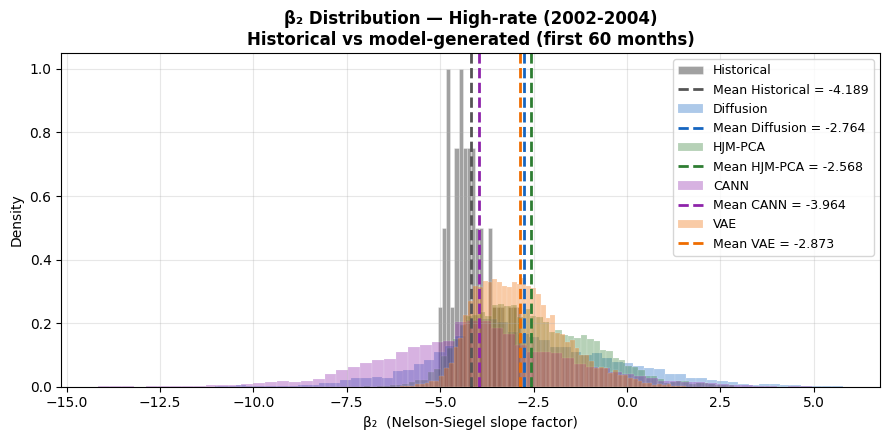

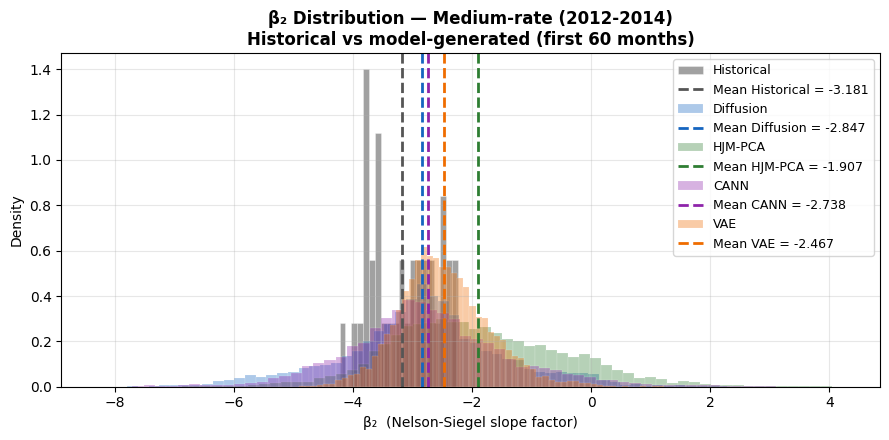

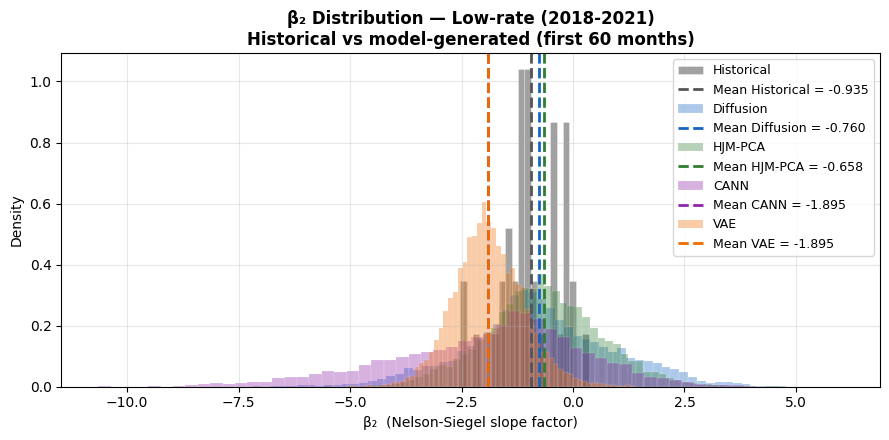

In [67]:
# ── Plot: one figure per regime, historical + all models ─────────────────────
for rid in sorted(hist_beta2.keys()):
    label    = REGIMES.get(rid, f"Curve {rid}")
    hist_b2  = hist_beta2[rid]

    fig, ax = plt.subplots(figsize=(9, 4.5))

    ax.hist(hist_b2, bins=20, density=True, alpha=0.55,
            color="#555555", edgecolor="white", linewidth=0.4, label="Historical")
    ax.axvline(hist_b2.mean(), color="#555555", linewidth=2, linestyle="--",
               label=f"Mean Historical = {hist_b2.mean():.3f}")

    for model_name, regime_b2 in model_beta2.items():
        if rid not in regime_b2:
            continue
        b2    = regime_b2[rid]
        color = MODEL_COLORS[model_name]
        ax.hist(b2, bins=60, density=True, alpha=0.35,
                color=color, edgecolor="white", linewidth=0.3, label=model_name)
        ax.axvline(b2.mean(), color=color, linewidth=2, linestyle="--",
                   label=f"Mean {model_name} = {b2.mean():.3f}")

    ax.set_title(f"β₂ Distribution — {label}\n"
                 f"Historical vs model-generated (first {N_MONTHS} months)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("β₂  (Nelson-Siegel slope factor)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


  High-rate (2002-2004): β₁=5.787  β₂=-4.214  β₃=-3.703
  Medium-rate (2012-2014): β₁=2.938  β₂=-2.886  β₃=-2.608
  Low-rate (2018-2021): β₁=3.062  β₂=-1.147  β₃=0.154


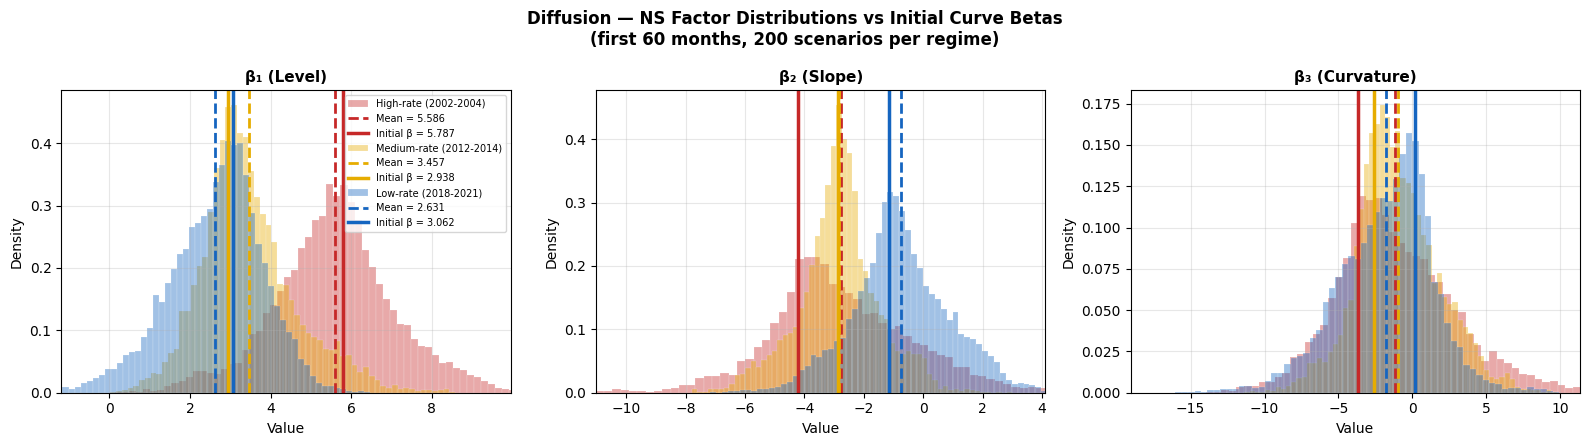

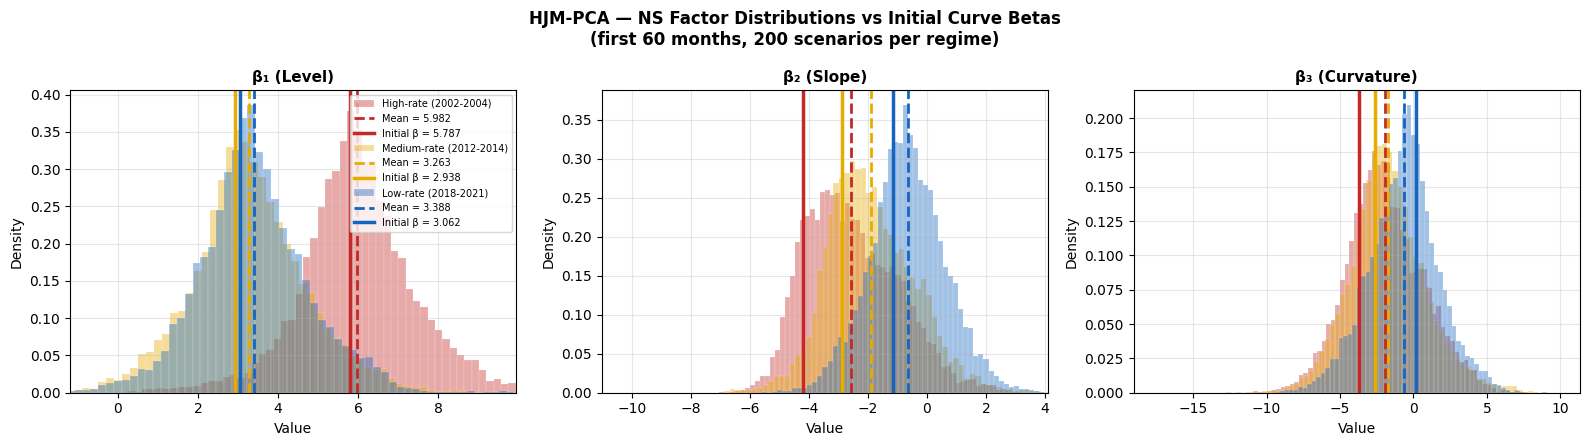

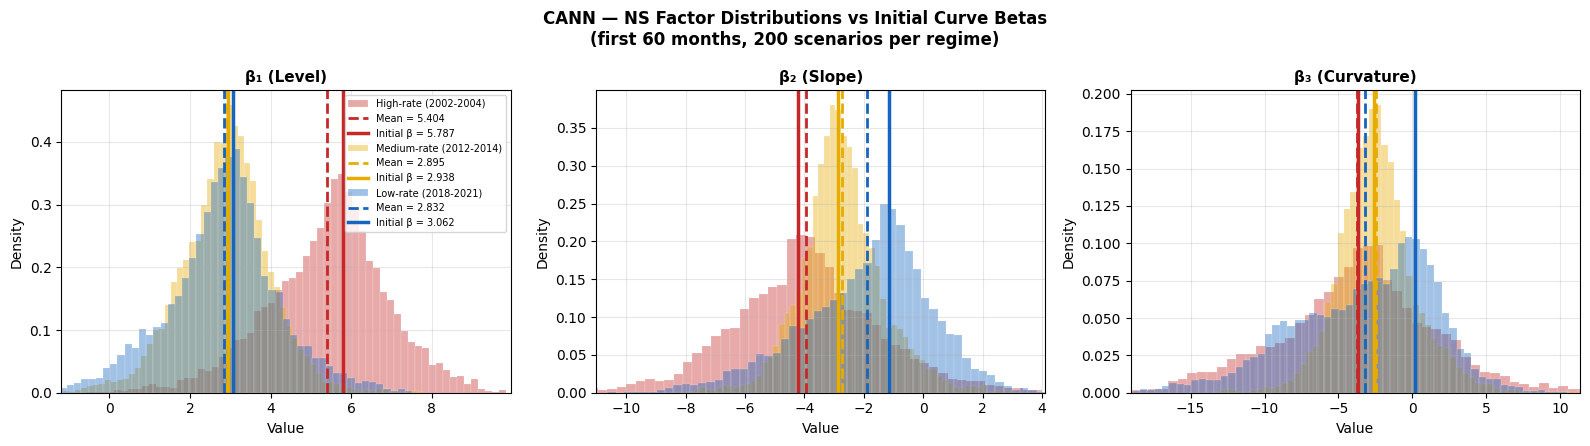

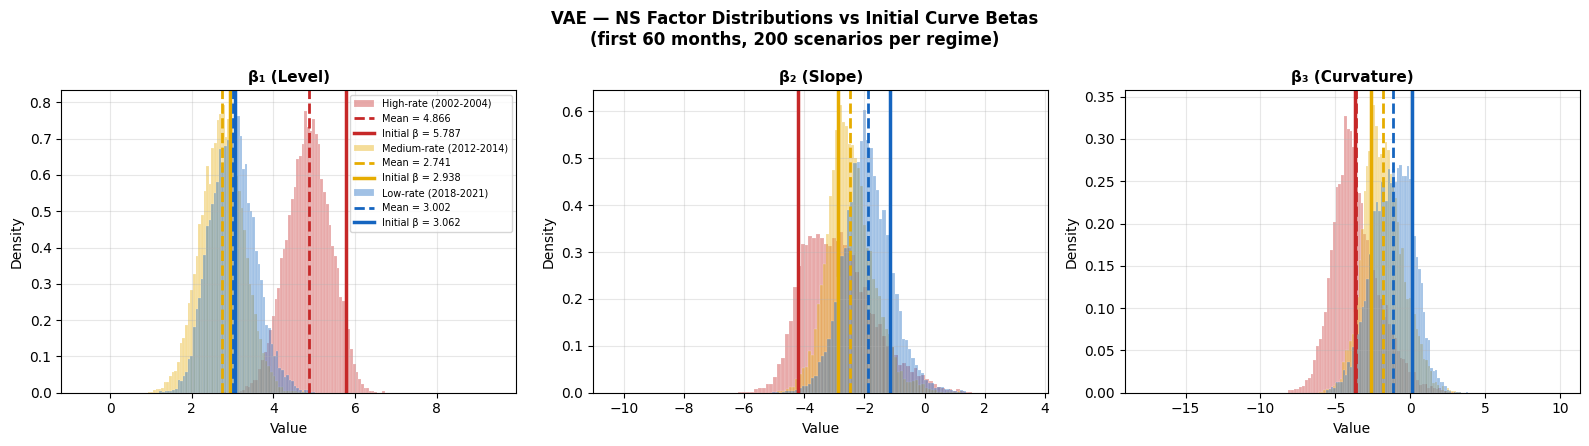

In [72]:
# ── Load initial curves and fit NS betas ─────────────────────────────────────
MAT_MONTHS = MAT_YEARS * 12

def ns_basis_months(t, lam=LAMBDA):
    lt = lam * t
    return np.column_stack([np.ones_like(t),
                            (1-np.exp(-lt))/lt,
                            (1-np.exp(-lt))/lt - np.exp(-lt)])

NS_BASIS_MO = ns_basis_months(MAT_MONTHS)

df_init = pd.read_csv("initial_curves.csv")
initial_betas = {}
for i, row in df_init.iterrows():
    b, *_ = lstsq(NS_BASIS_MO, row.values.astype(float), rcond=None)
    rid = i + 1
    initial_betas[rid] = b
    label = REGIMES.get(rid, f"Curve {rid}")
    print(f"  {label}: β₁={b[0]:.3f}  β₂={b[1]:.3f}  β₃={b[2]:.3f}")

# ── Compute global x-axis limits per beta factor across all models/regimes ────
BETA_LABELS = ["β₁ (Level)", "β₂ (Slope)", "β₃ (Curvature)"]
x_mins = [np.inf, np.inf, np.inf]
x_maxs = [-np.inf, -np.inf, -np.inf]

for model_name, regime_betas in model_betas.items():
    for rid, betas in regime_betas.items():
        for bi in range(3):
            vals = betas[:, bi]
            x_mins[bi] = min(x_mins[bi], np.percentile(vals, 0.5))
            x_maxs[bi] = max(x_maxs[bi], np.percentile(vals, 99.5))

# Also include initial beta values in the axis range
for rid, b0 in initial_betas.items():
    for bi in range(3):
        x_mins[bi] = min(x_mins[bi], b0[bi] - 0.2)
        x_maxs[bi] = max(x_maxs[bi], b0[bi] + 0.2)

# ── Plot β distributions with initial curve betas overlaid ───────────────────
for model_name, regime_betas in model_betas.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"{model_name} — NS Factor Distributions vs Initial Curve Betas\n"
                 f"(first {N_MONTHS} months, 200 scenarios per regime)",
                 fontsize=12, fontweight="bold")

    for bi, beta_label in enumerate(BETA_LABELS):
        ax = axes[bi]
        for rid, betas in sorted(regime_betas.items()):
            color = REGIME_COLORS[rid]
            label = REGIMES.get(rid, f"Curve {rid}")
            vals  = betas[:, bi]
            mean  = vals.mean()

            ax.hist(vals, bins=60, density=True, alpha=0.40,
                    color=color, edgecolor="white", linewidth=0.3, label=label)
            ax.axvline(mean, color=color, linewidth=2, linestyle="--",
                       label=f"Mean = {mean:.3f}")

            # Initial curve beta — bold solid vertical line
            if rid in initial_betas:
                b0 = initial_betas[rid][bi]
                ax.axvline(b0, color=color, linewidth=2.5, linestyle="-",
                           label=f"Initial β = {b0:.3f}")

        ax.set_xlim(x_mins[bi], x_maxs[bi])
        ax.set_title(beta_label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        ax.grid(True, alpha=0.3)
        if bi == 0:
            ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

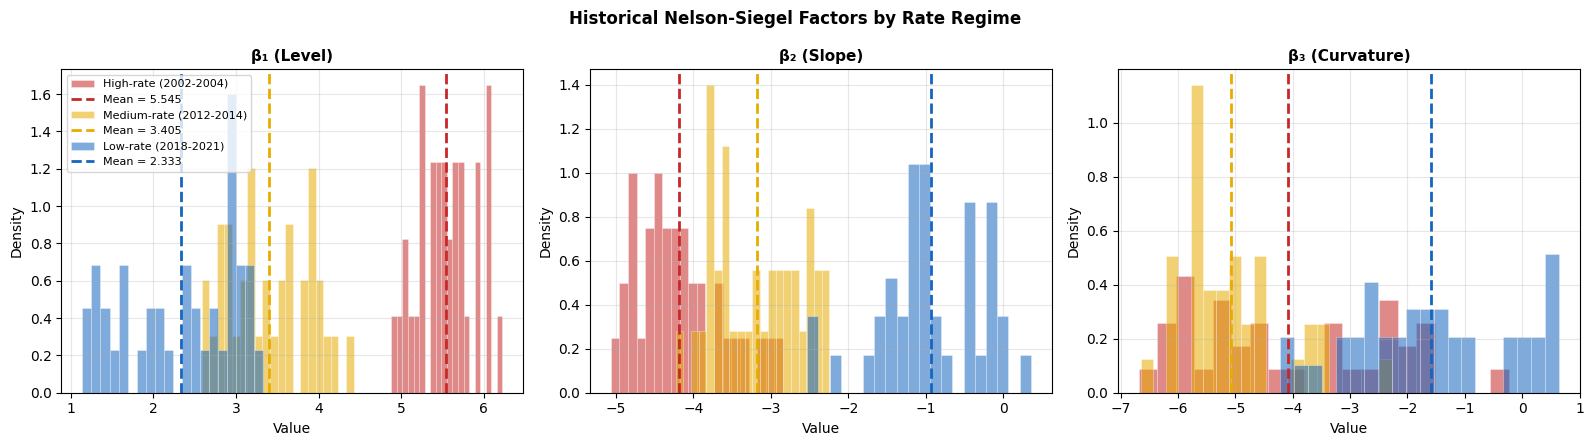

In [68]:
# ── Visualise historical β factors for each regime period ────────────────────
BETA_LABELS = ["β₁ (Level)", "β₂ (Slope)", "β₃ (Curvature)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Historical Nelson-Siegel Factors by Rate Regime",
             fontsize=12, fontweight="bold")

for bi, beta_label in enumerate(BETA_LABELS):
    ax = axes[bi]
    for rid, (start, end) in HIST_PERIODS.items():
        color = REGIME_COLORS[rid]
        label = REGIMES.get(rid, f"Curve {rid}")
        sub   = hist_monthly.loc[start:end]
        
        b_vals = []
        for _, row in sub.iterrows():
            b, *_ = lstsq(NS_BASIS, row.values.astype(float), rcond=None)
            b_vals.append(b[bi])
        b_vals = np.array(b_vals)
        
        ax.hist(b_vals, bins=20, density=True, alpha=0.55,
                color=color, edgecolor="white", linewidth=0.4, label=label)
        ax.axvline(b_vals.mean(), color=color, linewidth=2, linestyle="--",
                   label=f"Mean = {b_vals.mean():.3f}")
    
    ax.set_title(beta_label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    if bi == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [69]:
# ── Wasserstein distance: each model vs historical, per regime ────────────────
rows = []
for rid in sorted(hist_beta2.keys()):
    label   = REGIMES.get(rid, f"Curve {rid}")
    hist_b2 = hist_beta2[rid]
    for model_name, regime_b2 in model_beta2.items():
        if rid not in regime_b2:
            continue
        dist = wasserstein_distance(hist_b2, regime_b2[rid])
        rows.append({
            "Regime":      label,
            "Model":       model_name,
            "Wasserstein (model vs historical)": round(dist, 4),
        })

wass_hist_df = pd.DataFrame(rows)

print("=" * 70)
print("  Wasserstein Distance — Model β₂ vs Historical β₂")
print("  (lower = model distribution closer to historical pattern)")
print("=" * 70)
for rid in sorted(hist_beta2.keys()):
    label = REGIMES.get(rid, f"Curve {rid}")
    sub   = wass_hist_df[wass_hist_df["Regime"] == label]
    print(f"\n  {label}")
    print(sub.drop(columns="Regime").to_string(index=False))


  Wasserstein Distance — Model β₂ vs Historical β₂
  (lower = model distribution closer to historical pattern)

  High-rate (2002-2004)
    Model  Wasserstein (model vs historical)
Diffusion                             1.8348
  HJM-PCA                             1.6436
     CANN                             1.4981
      VAE                             1.3212

  Medium-rate (2012-2014)
    Model  Wasserstein (model vs historical)
Diffusion                             0.6962
  HJM-PCA                             1.3405
     CANN                             0.7179
      VAE                             0.7170

  Low-rate (2018-2021)
    Model  Wasserstein (model vs historical)
Diffusion                             0.7805
  HJM-PCA                             0.5486
     CANN                             1.3290
      VAE                             0.9653
